# From real curves
let us draw random affinity to generate activity curves and then derive the activity array at fixed concentration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from scipy.special import entr
import itertools

import sys
sys.path.append('../..')

from src.plot_helper import plot_grid_heatmap
from src.ligand_coding_model import *
from src.receptor_information import *

def plot_annotated_heatmap(data, counts, title="Receptor Activity"):
    # 1. Plot base heatmap
    im, ax = plot_grid_heatmap(data, figsize=(6,5))
    
    # 2. Key mapping (handles numeric keys 1, 2, 3)
    if isinstance(counts, dict):
        ordered_counts = [counts.get(1, 0), counts.get(2, 0), counts.get(3, 0)]
    else:
        ordered_counts = counts 

    labels = ["Homomers", "Hetero 2", "Hetero 3"]
    current_pos = -0.5
    
    for i, count in enumerate(ordered_counts):
        if count <= 0: continue  
        
        top = current_pos
        bottom = current_pos + count
        midpoint = (top + bottom) / 2
        
        # White divider lines
        if i < len(ordered_counts) - 1 and sum(ordered_counts[i+1:]) > 0:
            ax.axhline(bottom, color='white', linewidth=2.5, zorder=3)
            
        # --- ROTATED TEXT LABELS ---
        # x=-0.2 moves it very close to the axis
        # rotation=90 makes it vertical
        ax.text(-0.2, midpoint, labels[i], 
                ha='right', va='center', 
                rotation=90,
                fontweight='bold', 
                fontsize=10, 
                color='black',
                transform=ax.get_yaxis_transform())
        
        current_pos = bottom

    ax.set_title(title, pad=20)
    ax.set_xlabel("Ligands")
    
    # This ensures the new vertical labels aren't cut off by the figure edge
    plt.tight_layout()

    return im, ax

# --- 1. Define General Parameters ---
Nr = 3  # Number of receptors (e.g., r0, r1, r2)

# Binning parameters
# binning parameters influence the indexing of the response.
# this is why, we define them on top
Na,Nc = 10,10
# concentration bins
c_min = 0.01
c_max = 10.0
c_edges = np.logspace(np.log10(c_min), np.log10(c_max), Nc + 1)
c_centers = np.sqrt(c_edges[:-1] * c_edges[1:])
c_star = np.array([c_centers[c_centers.__len__()//2]])
# activity bins
a_edges = np.linspace(0, 1, Na + 1)
a_centers = 0.5*(a_edges[1:] + a_edges[:-1])
a_centers[0] = 0.
a_centers[-1] = 1.


In [3]:
Nreplicas = 1 # number of time we generate random ligands to perform averages
counts = {1:22,2:19,3:15}
L_values = np.array([96])
MI = np.zeros(L_values.shape[0],dtype=float)
for l_idx, L_curr in enumerate(L_values):
    mi_hetero = []
    for k in range(Nreplicas):
        Kcs_3hetero, Kos_3hetero, eps_3hetero = generate_Ks(L=L_curr, n_types=22, n_hetero_sample={2:19,3:15},Kc_Amp=50)
        A_3hetero_binned = generate_activity_matrix(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_star, a_edges,indices_to_avg=None)
        A_continuous = generate_continuous_A(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_centers, a_edges,indices_to_avg=None)
        mi_hetero.append(compute_mi(A_3hetero_binned))
    MI[l_idx] = np.mean(mi_hetero)


# 3. Concatenate them along the middle axis to get (L, 3, N)
print(A_3hetero_binned.shape)

(96, 56, 1)


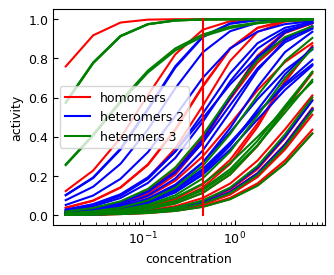

In [4]:
A_continuous.shape
for A in A_continuous[:1]:
    n= 0
    k=0
    for a in A:
        if n < counts[1]:
            color = 'red'
        elif n<counts[2]+counts[1]:
            color='blue'
        elif n< counts[3]+counts[2]+counts[1]:
            color='green'
        if n==0 :
            plt.plot(c_centers,a,color=color,label='homomers')
        elif n == counts[1]:
            plt.plot(c_centers,a,color=color,label='heteromers 2')
        elif  n ==counts[1]+counts[2]:
            plt.plot(c_centers,a,color=color,label='hetermers 3')
        else:
            plt.plot(c_centers,a,color=color)
        n+=1
plt.plot([c_star,c_star],[0,1],color='red')
plt.xscale('log')
plt.xlabel('concentration')
plt.ylabel('activity')
plt.legend()

mutual information = 4.564


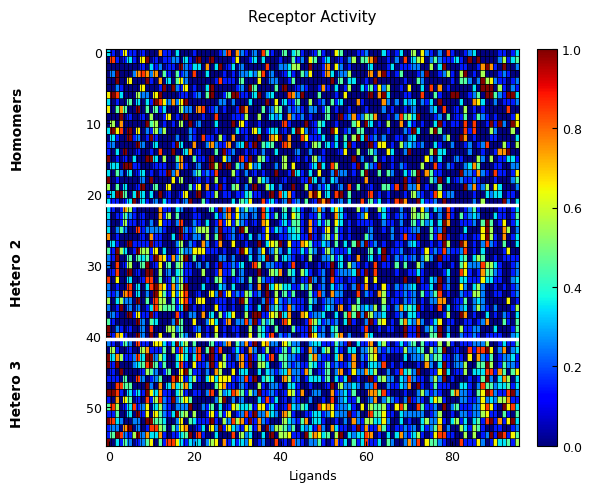

In [5]:
plot_annotated_heatmap(a_centers[A_3hetero_binned[:,:,0]].T,counts = {1:22,2:19,3:15},)#,figsize=(6,5))
print(f'mutual information = {MI[0]:.3f}')

In [6]:
Nreplicas = 1 # number of time we generate random ligands to perform averages
counts = {1:22}
L_values = np.array([96])
MI = np.zeros(L_values.shape[0],dtype=float)
for l_idx, L_curr in enumerate(L_values):
    mi_hetero = []
    for k in range(Nreplicas):
        Kcs_3hetero, Kos_3hetero, eps_3hetero = generate_Ks(L=L_curr, n_types=22, n_hetero_sample=0,Kc_Amp=50)
        A_3hetero_binned = generate_activity_matrix(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_star, a_edges,indices_to_avg=None)
        A_continuous = generate_continuous_A(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_centers, a_edges,indices_to_avg=None)
        mi_hetero.append(compute_mi(A_3hetero_binned))
    MI[l_idx] = np.mean(mi_hetero)

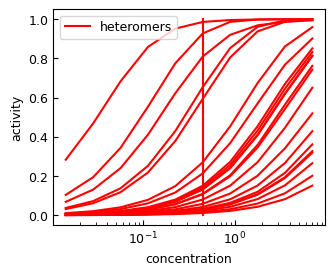

In [7]:
A_continuous.shape
for A in A_continuous[:1]:
    n= 0
    for a in A:
        if n <= counts[1]:
            color = 'red'
        elif n<=counts[2]+counts[1]:
            color='blue'
        elif n<= counts[3]+counts[2]+counts[1]:
            color='green'
        if n==0:
            plt.plot(c_centers,a,color=color,label='heteromers')
        else:
            plt.plot(c_centers,a,color=color)
        n+=1
plt.plot([c_star,c_star],[0,1],color='red')
plt.xscale('log')
plt.xlabel('concentration')
plt.ylabel('activity')
plt.legend()

mutual information = 4.564


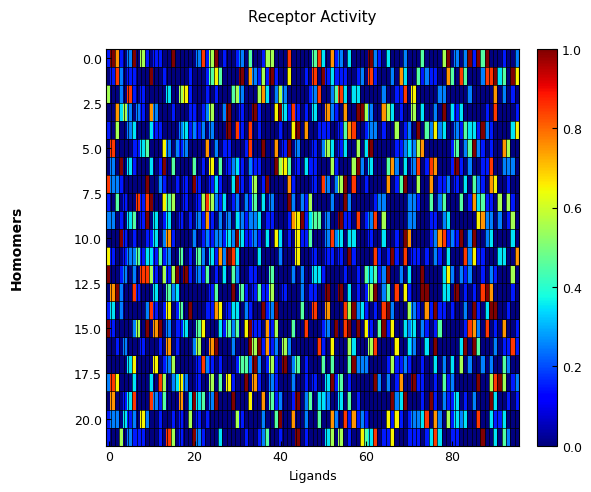

In [8]:
plot_annotated_heatmap(a_centers[A_3hetero_binned[:,:,0]].T,counts = {1:22},)#,figsize=(6,5))
print(f'mutual information = {MI[0]:.3f}')

# What if we had SOOOOO MUCH MORE LIGANDS !!!

## Here we only use 5 different units

In [31]:
L_values = np.logspace(1,5,4).astype(int)
print(L_values)

[    10    215   4641 100000]


In [32]:
Nreplicas = 1 # number of time we generate random ligands to perform averages
counts = {1:22}
MI_homo = np.zeros(L_values.shape[0],dtype=float)
for l_idx, L_curr in enumerate(L_values):
    mi_homo = []
    for k in range(Nreplicas):
        Kcs_3hetero, Kos_3hetero, eps_3hetero = generate_Ks(L=L_curr, n_types=5, n_hetero_sample=0,Kc_Amp=50)
        A_3hetero_binned = generate_activity_matrix(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_star, a_edges,indices_to_avg=None)
        A_continuous = generate_continuous_A(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_centers, a_edges,indices_to_avg=None)
        mi_homo.append(compute_mi(A_3hetero_binned))
    MI_homo[l_idx] = np.mean(mi_homo)

In [33]:
Nreplicas = 1 # number of time we generate random ligands to perform averages
counts = {1:22,2:19,3:15}

MI_hetero = np.zeros(L_values.shape[0],dtype=float)
for l_idx, L_curr in enumerate(L_values):
    mi_hetero = []
    for k in range(Nreplicas):
        Kcs_3hetero, Kos_3hetero, eps_3hetero = generate_Ks(L=L_curr, n_types=5, n_hetero_sample={2:19,3:15},Kc_Amp=50)
        A_3hetero_binned = generate_activity_matrix(eps_3hetero, Kcs_3hetero, Kos_3hetero, c_star, a_edges,indices_to_avg=None)
        mi_hetero.append(compute_mi(A_3hetero_binned))
    MI_hetero[l_idx] = np.mean(mi_hetero)
# 3. Concatenate them along the middle axis to get (L, 3, N)
print(A_3hetero_binned.shape)

(100000, 39, 1)


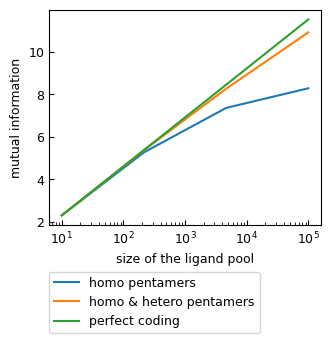

In [ ]:
plt.plot (L_values,MI_homo,label='homo pentamers')
plt.plot (L_values,MI_hetero,label='homo & hetero pentamers')
plt.plot(L_values,np.log(L_values),label='perfect coding')

plt.xscale('log')
plt.xlabel('size of the ligand pool')
plt.ylabel('mutual information')
plt.legend(loc=(0,-0.5))
plt.title('mutual information for a large pool of ligand')